In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import torchvision.transforms as transforms
import os
import pandas as pd
from PIL import Image
from collections import Counter

import spacy

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

In [2]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 13.4 MB/s eta 0:00:01
     ----------- ---------------------------- 3.7/12.8 MB 12.1 MB/s eta 0:00:01
     ---------------- ----------------------- 5.2/12.8 MB 10.6 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 10.6 MB/s eta 0:00:01
     --------------------------------- ----- 11.0/12.8 MB 11.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 11.3 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
spacy_eng = spacy.load("en_core_web_sm")

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {
            0: "<PAD>",
            1: "<SOS>",
            2: "<EOS>",
            3: "<UNK>"
        }

        self.stoi = {
            "<PAD>": 0,
            "<SOS>": 1,
            "<EOS>": 2,
            "<UNK>": 3
        }

        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)

        self.transform = transform

        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]

        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<SOS>"]]

        numericalized_caption += self.vocab.numericalize(caption)

        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]

        imgs = torch.cat(imgs, dim=0)

        targets = [item[1] for item in batch]

        targets = pad_sequence(
            targets,
            batch_first=True,
            padding_value=self.pad_idx
        )

        return imgs, targets

def get_loader(
    root_folder,
    annotation_file,
    transform,
    batch_size=128,
    num_workers=0,
    shuffle=True,
    pin_memory=True,
):

    dataset = FlickrDataset(
        root_folder,
        annotation_file,
        transform=transform
    )

    pad_idx = dataset.vocab.stoi["<PAD>"]

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=MyCollate(pad_idx=pad_idx),
    )

    return loader, dataset

def tokens_to_caption(tokens, vocab):

    words = []

    for token in tokens:

        word = vocab.itos[token]

        if word == "<EOS>":
            break

        if word not in ["<SOS>", "<PAD>"]:
            words.append(word)

    return " ".join(words)

Models

In [4]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN = False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
        self.inception.aux_logits = False
        self.inception.AuxLogits = None
        self.inception.fc = nn.Linear(self.inception.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        for param in self.inception.parameters():
            param.requires_grad = train_CNN

        for param in self.inception.fc.parameters():
            param.requires_grad = True

    def forward(self, images):
        features = self.inception(images)
        return self.dropout(self.relu(features))


class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        features = features.unsqueeze(1)
        embeddings = torch.cat((features, embeddings), dim=1)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.linear(hiddens)
        return outputs

class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=50):
        result_caption = []
        self.eval()
        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)
            states = None

            for _ in range(max_length):
                hiddens, states = self.decoderRNN.lstm(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(1)

                result_caption.append(predicted.item())
                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocabulary.itos[predicted.item()] == "<EOS>":
                    break
        self.train()
        return [vocabulary.itos[idx] for idx in result_caption]


In [5]:
import os

print(os.path.exists("../flickr8k/Images"))
print(os.path.exists("../flickr8k/captions.txt"))

True
True


In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize((356, 356)),
        transforms.RandomCrop((299,299)),
        transforms.ToTensor(),
        transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]),
    ]
)

# train_loader, dataset = get_loader(
#     root_folder="flickr8k/Images",
#     annotation_file="flickr8k/captions.txt",
#     transform=transform,
#     num_workers=0,
# )

full_dataset = FlickrDataset(
    root_dir="../flickr8k/Images",
    captions_file="../flickr8k/captions.txt",
    transform=transform
)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset,[train_size, val_size, test_size])
pad_idx = full_dataset.vocab.stoi["<PAD>"]

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=MyCollate(pad_idx)
)

#Hyperparamaters
embed_size = 256
hidden_size = 256
vocab_size = len(full_dataset.vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 100


#initialize model, loss etc
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=full_dataset.vocab.stoi["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

Train

In [ ]:
max_loss = float('inf')
val_max_loss = float('inf')
noLossProgression = 0
indexLossProgression = 0
for epoch in range(num_epochs):
    #------------------------- TRAINING -------------------------
    model.train()
    running_loss = 0
    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)

        outputs = model(imgs, captions[:, :-1])
        loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        running_loss += loss.item()
    average_loss = running_loss/len(train_loader)
    #------------------------- VALIDATION -------------------------
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for imgs, captions in val_loader:
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions[:,:-1])
            val_loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]),captions[:, 1:].reshape(-1))
            val_running_loss += val_loss.item()
        val_average_loss = val_running_loss/len(val_loader)
        if val_average_loss <= val_max_loss:
                val_max_loss = val_average_loss
                torch.save(model.state_dict(), "BestModel.pth")
                print("Saved the Best Performing Model!")
                indexLossProgression = epoch +1
    print(f"Epoch [{epoch + 1}/{num_epochs}] Training Loss: {average_loss:.4f} Validation Loss: {val_average_loss:.4f}")
    if epoch >= 5 and epoch - indexLossProgression >= 5:
        break

Saved the Best Performing Model!
Epoch [1/100] Training Loss: 4.2271 Validation Loss: 3.6571
Saved the Best Performing Model!
Epoch [2/100] Training Loss: 3.5380 Validation Loss: 3.3763
Saved the Best Performing Model!
Epoch [3/100] Training Loss: 3.3120 Validation Loss: 3.2213
Saved the Best Performing Model!
Epoch [4/100] Training Loss: 3.1709 Validation Loss: 3.1070
Saved the Best Performing Model!
Epoch [5/100] Training Loss: 3.0592 Validation Loss: 3.0213
Saved the Best Performing Model!
Epoch [6/100] Training Loss: 2.9693 Validation Loss: 2.9484
Saved the Best Performing Model!
Epoch [7/100] Training Loss: 2.8997 Validation Loss: 2.9034
Saved the Best Performing Model!
Epoch [8/100] Training Loss: 2.8406 Validation Loss: 2.8610
Saved the Best Performing Model!
Epoch [9/100] Training Loss: 2.7920 Validation Loss: 2.8283
Saved the Best Performing Model!
Epoch [10/100] Training Loss: 2.7496 Validation Loss: 2.8013
Saved the Best Performing Model!
Epoch [11/100] Training Loss: 2.7106

C:\Users\david\AppData\Local\Temp\ipykernel_15988\2559621217.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("BestModel.pth"))



----------------------------------
Actual Caption    : a white dog is <UNK> on a brown dog in a fenced in backyard .
Predicted Caption : two dogs are fighting over a red and white pole . 


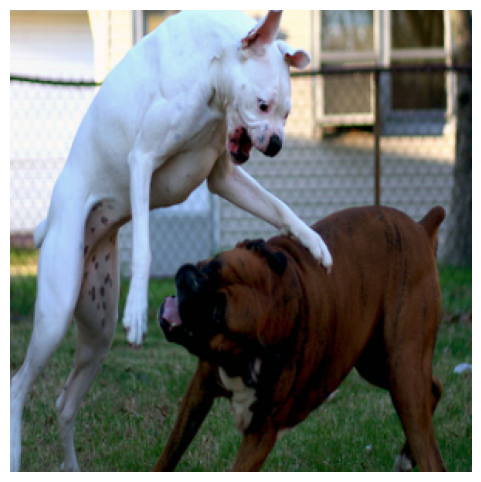


----------------------------------
Actual Caption    : a dog is running through a sprinkler in the grass .
Predicted Caption : dog running on the grass . 


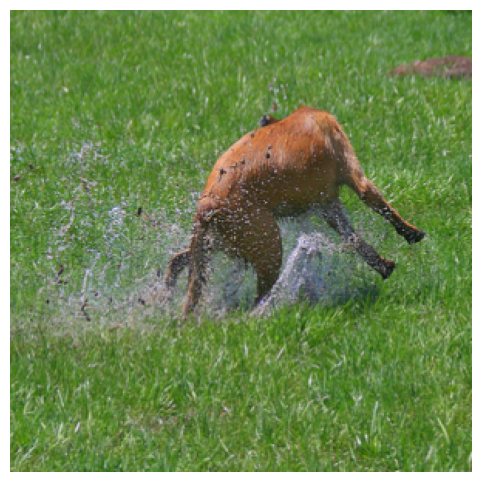


----------------------------------
Actual Caption    : a group of people are sitting on the porch of a brick building .
Predicted Caption : people are gathered in front of a building . 


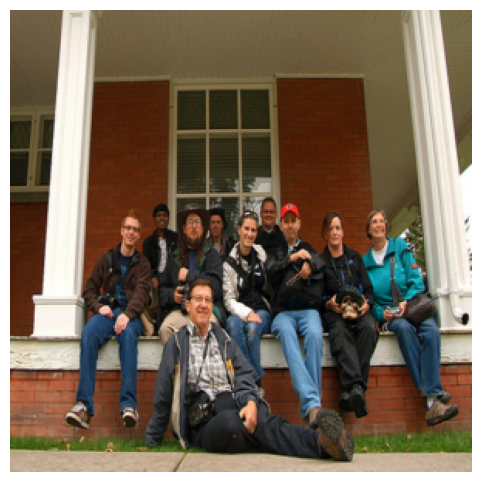


Final Test Loss: 2.7319


In [7]:
#Test the model
model.load_state_dict(torch.load("BestModel.pth"))
model.eval()

test_loss = 0.0
correct = 0
total = 0
test_running_loss = 0.0

with torch.no_grad():

    for batch_idx, (imgs, captions) in enumerate(test_loader):

        imgs = imgs.to(device)
        captions = captions.to(device)

        # Forward pass
        outputs = model(imgs, captions[:, :-1])

        # Compute test loss
        loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
        test_running_loss += loss.item()

        # Show a few predictions from first batch only
        if batch_idx == 0:

            for i in range(min(3, imgs.shape[0])):
                # Generate predicted caption
                predicted_caption = model.caption_image(imgs[i].unsqueeze(0), full_dataset.vocab)

                predicted_sentence = " ".join(predicted_caption)

                # Convert actual caption to text
                actual_sentence = tokens_to_caption(captions[i].cpu().numpy(), full_dataset.vocab)

                # Prepare image for matplotlib
                img = imgs[i].cpu()

                # Convert CHW -> HWC
                img = img.permute(1, 2, 0)

                # Undo normalization
                mean = torch.tensor([0.485, 0.456, 0.406])
                std = torch.tensor([0.229, 0.224, 0.225])

                img = img * std + mean
                img = img.clamp(0, 1)

                # Plot image
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.axis("off")

                print("\n----------------------------------")
                print(f"Actual Caption    : {actual_sentence}")
                print(f"Predicted Caption : {predicted_sentence[:-5]}")

                plt.show()

# Average test loss
average_test_loss = test_running_loss / len(test_loader)

print(f"\nFinal Test Loss: {average_test_loss:.4f}")

## With Beam Search 
(Higher Grade --> bombaclat deluxe edition)

In [12]:
def caption_image_beam_search(self, image, vocabulary, beam_width=3, max_length=20):
    self.eval()

    eos_idx = vocabulary.stoi["<EOS>"]
    pad_idx = vocabulary.stoi["<PAD>"]

    with torch.no_grad():
        features = self.encoderCNN(image).unsqueeze(0)
        beams = [(features, None, [], 0.0)]

        for _ in range(max_length):
            candidates = []

            for x, states, tokens, score in beams:
                if len(tokens) > 0 and tokens[-1] == eos_idx:
                    candidates.append((x, states, tokens, score))
                    continue

                hiddens, new_states = self.decoderRNN.lstm(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))

                log_probs = torch.log_softmax(output, dim=1)
                top_probs, top_indices = log_probs.topk(beam_width, dim=1)

                for i in range(beam_width):
                    word_idx = top_indices[0, i].item()
                    word_score = top_probs[0, i].item()

                    new_tokens = tokens + [word_idx]
                    new_score = score + word_score

                    next_input = self.decoderRNN.embed(
                        torch.tensor([word_idx]).to(image.device)
                    ).unsqueeze(0)

                    candidates.append((next_input, new_states, new_tokens, new_score))

            beams = sorted(
                candidates,
                key=lambda x: x[3] / len(x[2]),
                reverse=True
            )[:beam_width]

            if all(len(tokens) > 0 and tokens[-1] == eos_idx for _, _, tokens, _ in beams):
                break

    self.train()

    best_tokens = beams[0][2]

    return [
        vocabulary.itos[idx]
        for idx in best_tokens
        if idx not in [eos_idx, pad_idx]
    ]

CNNtoRNN.caption_image_beam_search = caption_image_beam_search

C:\Users\david\AppData\Local\Temp\ipykernel_15988\2081503064.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("BestModel.pth", map_locati


----------------------------------
Actual Caption : a white dog is <UNK> on a brown dog in a fenced in backyard .
Greedy Caption : two dogs are fighting over a red and white pole .
Beam Caption   : two white dogs are playing in the snow .


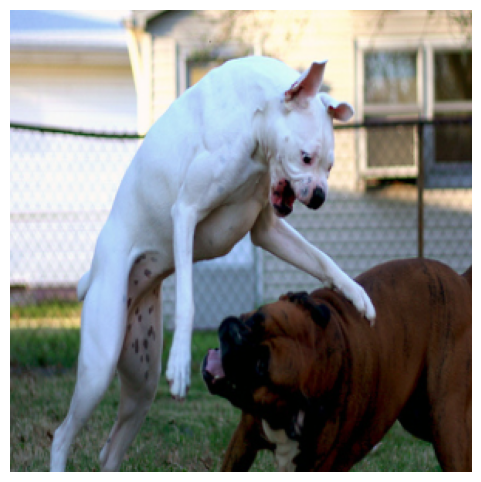


----------------------------------
Actual Caption : a dog is running through a sprinkler in the grass .
Greedy Caption : dog running on the grass .
Beam Caption   : two dogs are running through a grassy field .


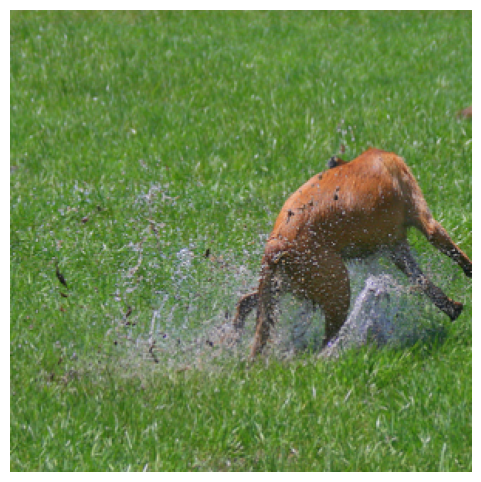


----------------------------------
Actual Caption : a group of people are sitting on the porch of a brick building .
Greedy Caption : people are sitting at a table in a restaurant .
Beam Caption   : a group of people are standing in front of a building .


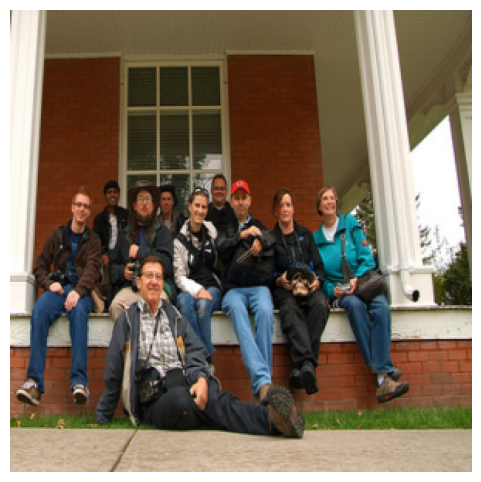


Final Test Loss: 2.7305


In [ ]:
#Test the model
model.load_state_dict(torch.load("BestModel.pth", map_location=device))
model.to(device)
print("Model is on:", next(model.parameters()).device)
model.eval()


test_running_loss = 0.0

with torch.no_grad():

    for batch_idx, (imgs, captions) in enumerate(test_loader):

        imgs = imgs.to(device)
        captions = captions.to(device)

        # Forward pass
        outputs = model(imgs, captions[:, :-1])

        # Compute test loss
        loss = criterion(outputs[:, 1:, :].reshape(-1, outputs.shape[2]), captions[:, 1:].reshape(-1))
        test_running_loss += loss.item()

        # Show a few predictions from first batch only
        if batch_idx == 0:

            for i in range(min(3, imgs.shape[0])):
                # Generate predicted caption
                greedy_caption = model.caption_image(imgs[i].unsqueeze(0), full_dataset.vocab)

                beam_caption = model.caption_image_beam_search(imgs[i].unsqueeze(0), full_dataset.vocab, beam_width=3)

                greedy_sentence = " ".join(greedy_caption).replace("<EOS>", "").strip()
                beam_sentence = " ".join(beam_caption).strip()

                # Convert actual caption to text
                actual_sentence = tokens_to_caption(captions[i].cpu().numpy(), full_dataset.vocab)

                # Prepare image for matplotlib
                img = imgs[i].cpu()

                # Convert CHW -> HWC
                img = img.permute(1, 2, 0)

                # Undo normalization
                mean = torch.tensor([0.485, 0.456, 0.406])
                std = torch.tensor([0.229, 0.224, 0.225])

                img = img * std + mean
                img = img.clamp(0, 1)

                # Plot image
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.axis("off")

                print("\n----------------------------------")
                print(f"Actual Caption : {actual_sentence}")
                print(f"Greedy Caption : {greedy_sentence}")
                print(f"Beam Caption   : {beam_sentence}")  

                plt.show()

# Average test loss
average_test_loss = test_running_loss / len(test_loader)

print(f"\nFinal Test Loss: {average_test_loss:.4f}")